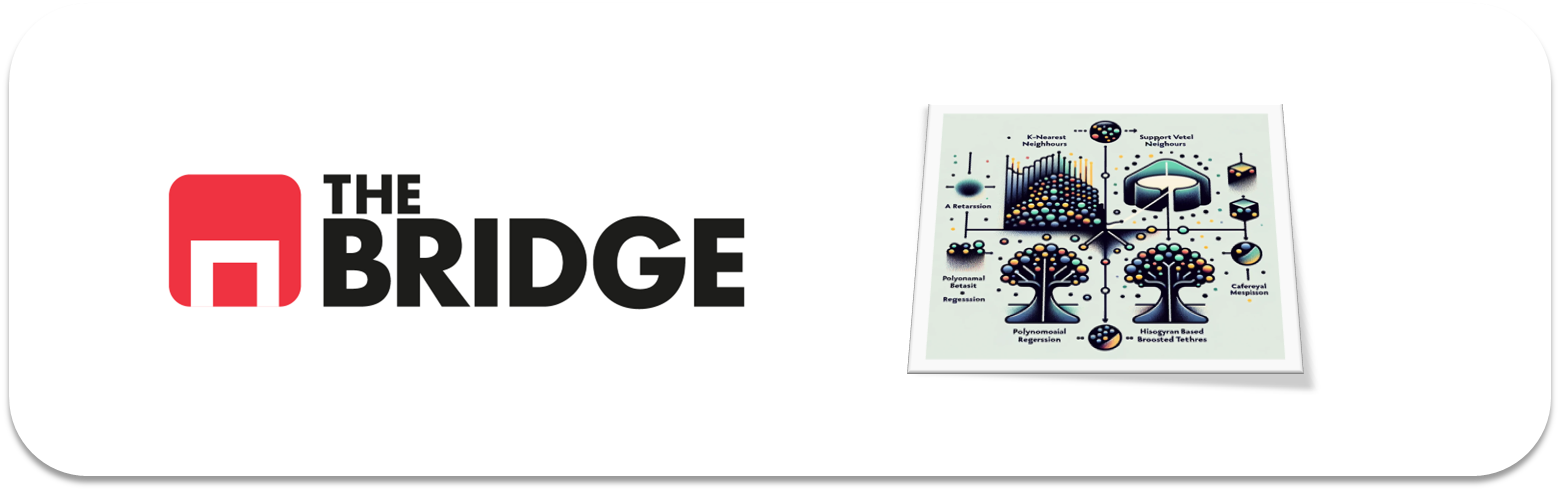

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import toolbox_ML_v2 as tl
import bootcampviztools as bt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv('data/credit_npo.csv')
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [4]:
tl.describe_df(df)

Clasificación sugerida para 12537 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Columnas,,,,,,,,,,,
Tipo_Dato,int64,float64,int64,int64,float64,float64,int64,int64,int64,int64,float64
Nulos,0,0,0,0,0,721,0,0,0,0,177
Nulos_%,0.0,0.0,0.0,0.0,0.0,5.8,0.0,0.0,0.0,0.0,1.4
Cardinalidad,2,10764,78,10,11547,4167,43,13,16,8,10
Cardinalidad_%,0.02,85.86,0.62,0.08,92.1,33.24,0.34,0.1,0.13,0.06,0.08
Clasificacion_sugerida,Categorica_Binaria,Numerica_Continua,Numerica_Discreta,Categorica_Nominal,Numerica_Continua,Numerica_Continua,Numerica_Discreta,Numerica_Discreta,Numerica_Discreta,Categorica_Nominal,Categorica_Nominal


| Columna                                | Qué significa                                                                                                                 | Tipo / unidad (habitual)                             | Nota útil                                             |
| -------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------- | ----------------------------------------------------- |
| `SeriousDlqin2yrs`                     | Variable objetivo: indica si la persona tuvo **mora grave** (≥90 días de atraso) **en los próximos 2 años**                   | Binaria (0/1)                                        | 1 = evento (default/mora grave), 0 = no evento        |
| `RevolvingUtilizationOfUnsecuredLines` | Proporción de uso de líneas de crédito **no garantizadas** (tarjetas/líneas revolventes) respecto del límite total disponible | Continua (ratio)                                     | Puede haber valores > 1; outliers frecuentes          |
| `age`                                  | Edad del solicitante                                                                                                          | Entero (años)                                        | Revisar extremos (0 o muy altos) por posibles errores |
| `NumberOfTime30-59DaysPastDueNotWorse` | Número de veces con mora **30–59 días** (sin llegar a peor)                                                                   | Entero (conteo)                                      | Puede tener outliers                                  |
| `DebtRatio`                            | Ratio de deuda (relación deuda/capacidad/ingreso según definición del dataset)                                                | Continua (ratio)                                     | Suele tener cola larga y outliers                     |
| `MonthlyIncome`                        | Ingreso mensual                                                                                                               | Continua (moneda)                                    | Tiene nulos en tu df (faltantes)                      |
| `NumberOfOpenCreditLinesAndLoans`      | Número de líneas de crédito abiertas y préstamos activos                                                                      | Entero (conteo)                                      | Proxy de exposición crediticia                        |
| `NumberOfTimes90DaysLate`              | Número de veces con mora **≥ 90 días**                                                                                        | Entero (conteo)                                      | Muy informativa; revisar valores extremos             |
| `NumberRealEstateLoansOrLines`         | Número de préstamos/líneas inmobiliarias (hipoteca, etc.)                                                                     | Entero (conteo)                                      | Suele ser bajo                                        |
| `NumberOfTime60-89DaysPastDueNotWorse` | Número de veces con mora **60–89 días** (sin llegar a peor)                                                                   | Entero (conteo)                                      | Similar a 30–59; puede tener outliers                 |
| `NumberOfDependents`                   | Número de dependientes (personas a cargo)                                                                                     | Conceptualmente entero (en tu df aparece como float) | Tiene nulos; suele imputarse y tratarse como entero   |


## Separamos en Train y test

In [5]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Imputacion de nulos

In [6]:
mediana_MonthlyIncome = train_set.MonthlyIncome.median()
train_set.MonthlyIncome = train_set.MonthlyIncome.fillna(mediana_MonthlyIncome)
test_set.MonthlyIncome = test_set.MonthlyIncome.fillna(mediana_MonthlyIncome)

In [7]:
mediana_NumberOfDependents = train_set.NumberOfDependents.median()
train_set.NumberOfDependents = train_set.NumberOfDependents.fillna(mediana_NumberOfDependents)
test_set.NumberOfDependents = test_set.NumberOfDependents.fillna(mediana_NumberOfDependents)

In [8]:
# test_set.isna().sum() # Chequeamos que no haya mas nulos

### Tratamiendo de variables

In [9]:
f_num_con = ['RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio',
 'MonthlyIncome']
f_num_dis = ['age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [10]:
for col in f_num_con:
    s = train_set[col]
    print(col,
          "nulos:", s.isna().sum(),
          "ceros:", (s == 0).sum(),
          "negativos:", (s < 0).sum(),
          "min:", s.min())

RevolvingUtilizationOfUnsecuredLines nulos: 0 ceros: 702 negativos: 0 min: 0.0
DebtRatio nulos: 0 ceros: 352 negativos: 0 min: 0.0
MonthlyIncome nulos: 0 ceros: 28 negativos: 0 min: 0.0


#### Aplico log a las numericas continuas

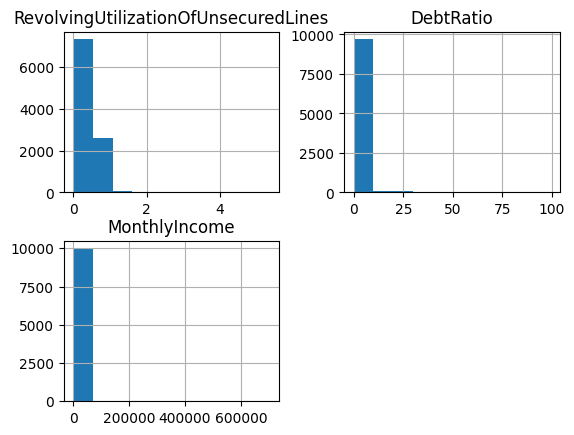

In [11]:
train_set[f_num_con].hist();

In [12]:
train_set[f_num_con] = np.log1p(train_set[f_num_con])
test_set[f_num_con]  = np.log1p(test_set[f_num_con])

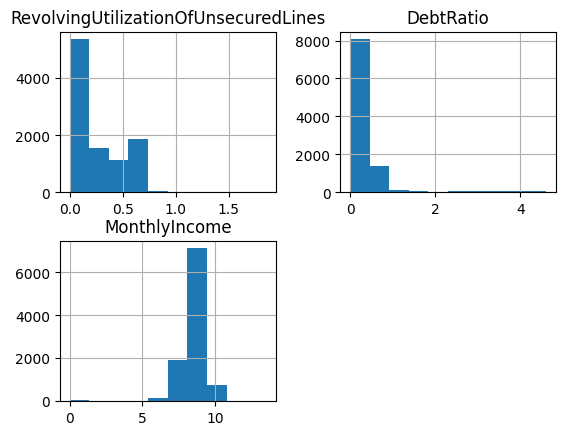

In [13]:
train_set[f_num_con].hist();

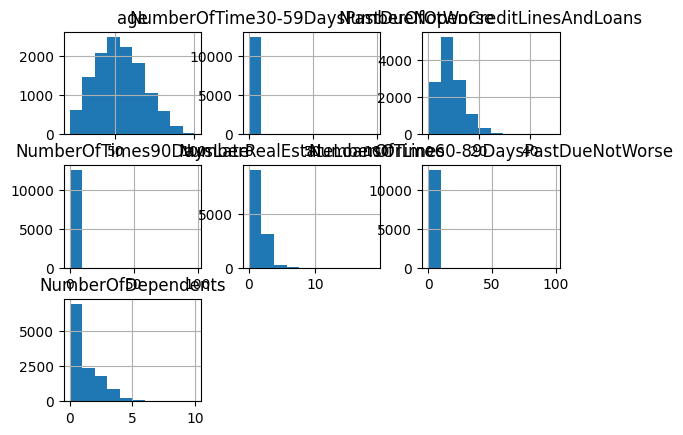

In [14]:
df[f_num_dis].hist();

In [15]:
features = f_num_con + f_num_dis

In [16]:
scaler = StandardScaler()
train_scaled = train_set.copy()
test_scaled  = test_set.copy()

train_scaled[features] = scaler.fit_transform(train_scaled[features])
test_scaled[features] = scaler.transform(test_scaled[features])

In [17]:
# train_scaled.describe()

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Nuestro poblema es de clasificacion ya que nuestro variable target es una categorica binaria

In [18]:
target = 'SeriousDlqin2yrs'

### #1.3
Pinta la distribución de frecuencias del target y coméntala

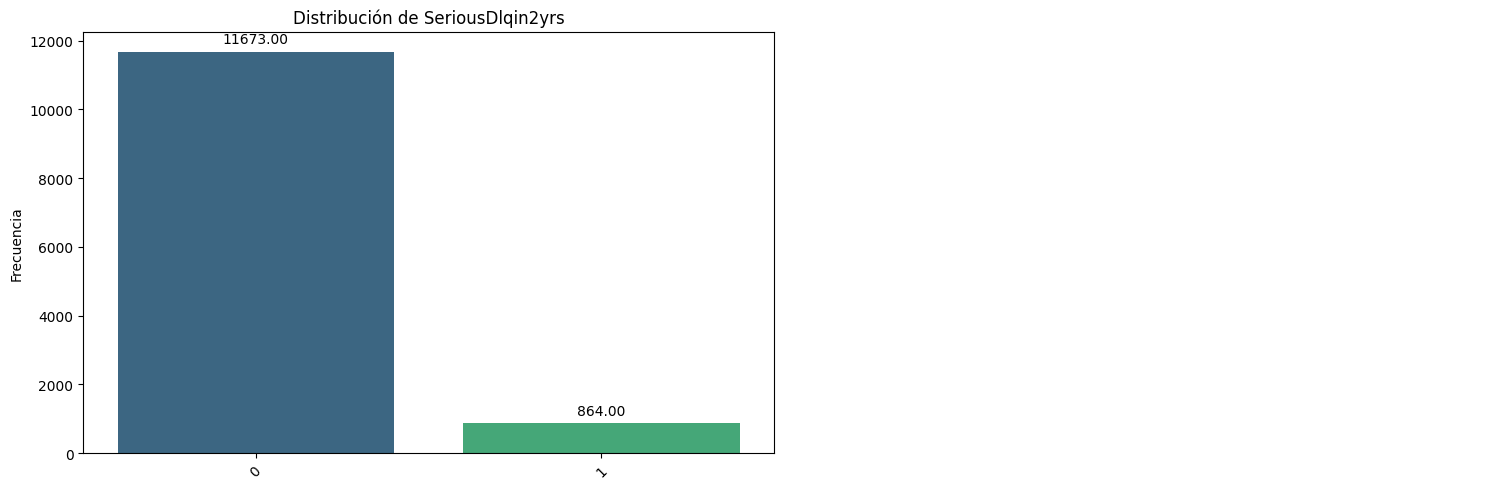

In [19]:
bt.pinta_distribucion_categoricas(df, [target], mostrar_valores=True)

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [20]:
# Train y test sin escalar :
X_train = train_set[features].copy()
X_test = test_set[features].copy()
y_train = train_set[target].copy()
y_test =  test_set[target].copy()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10029, 10)
(2508, 10)
(10029,)
(2508,)


In [21]:
# Train y test escalado :
X_train_scaled = train_scaled[features].copy()
X_test_scaled = test_scaled[features].copy()
y_train_scaled = train_scaled[target].copy()
y_test_scaled =  test_scaled[target].copy()

print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train_scaled.shape)
print(y_test_scaled.shape)

(10029, 10)
(2508, 10)
(10029,)
(2508,)


### Elegimos modelos 

In [22]:
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [23]:
rf_clf = RandomForestClassifier(max_depth=5, random_state= 42)
cat_clf = CatBoostClassifier(max_depth=5, random_state= 42, verbose = False)
knn = KNeighborsClassifier(n_neighbors=3)

In [24]:
nombres = ['Random Forest', 'CatBoost', 'KNN']
modelos = [rf_clf,cat_clf,knn]

In [25]:
metrica = {}
for name,model in zip(nombres, modelos):
    if name == 'KNN':
        valores = cross_val_score(model, X_train_scaled, y_train_scaled, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)
    else:
        valores = cross_val_score(model, X_train, y_train, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)

metrica

{'Random Forest': np.float64(0.5533454586938904),
 'CatBoost': np.float64(0.5991934750244966),
 'KNN': np.float64(0.5466847009903161)}

##### **Sobremuestreo o Over-Sampling**

In [26]:
smote = SMOTE(random_state= 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_sc_smote, y_train_sc_smote = smote.fit_resample(X_train_scaled, y_train_scaled)

In [27]:
metrica = {}
for name,model in zip(nombres, modelos):
    if name == 'KNN':
        valores = cross_val_score(model, X_train_sc_smote, y_train_sc_smote, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)
    else:
        valores = cross_val_score(model,X_train_smote, y_train_smote, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)

metrica

{'Random Forest': np.float64(0.7832320128575994),
 'CatBoost': np.float64(0.8825555892256239),
 'KNN': np.float64(0.9156307259944766)}

In [28]:
for name,model in zip(nombres, modelos):
    if name == 'KNN':
        print(name)
        model.fit( X_train_sc_smote, y_train_sc_smote)
        y_pred = model.predict(X_test_scaled)
        print(classification_report(y_test_scaled, y_pred))
    else:
        print(name)
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred))
        

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.73      0.83      2345
           1       0.16      0.75      0.27       163

    accuracy                           0.73      2508
   macro avg       0.57      0.74      0.55      2508
weighted avg       0.92      0.73      0.80      2508

CatBoost
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2345
           1       0.21      0.44      0.29       163

    accuracy                           0.86      2508
   macro avg       0.59      0.66      0.60      2508
weighted avg       0.91      0.86      0.88      2508

KNN
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2345
           1       0.17      0.40      0.24       163

    accuracy                           0.84      2508
   macro avg       0.56      0.63      0.58      2508
weighted avg       0.90      0.84      0.87    

##### **Over-Sampling = Nos quedariamos con Random Forest 0-0.73 y 1-0.75**

##### **Bajomuestreo o Under-Sampling**

In [29]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus =  rus.fit_resample(X_train, y_train)
X_train_sc_rus, y_train_sc_rus =  rus.fit_resample(X_train_scaled, y_train_scaled)

In [30]:
metrica = {}
for name,model in zip(nombres, modelos):
    if name == 'KNN':
        valores = cross_val_score(model,X_train_sc_rus, y_train_sc_rus, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)
    else:
        valores = cross_val_score(model, X_train_rus, y_train_rus , cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)

metrica

{'Random Forest': np.float64(0.7667822163530319),
 'CatBoost': np.float64(0.7745925192277122),
 'KNN': np.float64(0.6847633371238522)}

In [31]:
for name,model in zip(nombres, modelos):
    if name == 'KNN':
        print(name)
        model.fit( X_train_sc_rus, y_train_sc_rus)
        y_pred = model.predict(X_test_scaled)
        print(classification_report(y_test_scaled, y_pred))
    else:
        print(name)
        model.fit(X_train_rus, y_train_rus)
        y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      2345
           1       0.18      0.76      0.29       163

    accuracy                           0.76      2508
   macro avg       0.58      0.76      0.57      2508
weighted avg       0.93      0.76      0.82      2508

CatBoost
              precision    recall  f1-score   support

           0       0.98      0.78      0.87      2345
           1       0.19      0.73      0.30       163

    accuracy                           0.78      2508
   macro avg       0.58      0.76      0.59      2508
weighted avg       0.93      0.78      0.83      2508

KNN
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      2345
           1       0.16      0.66      0.26       163

    accuracy                           0.75      2508
   macro avg       0.56      0.71      0.55      2508
weighted avg       0.92      0.75      0.81    

##### **Under-Sampling = Nos quedariamos con Random Forest 0-0.76 y 1-0.76**

##### **Modificación de pesos en la función de pérdida o de selección de ramas (el class-weight)**

In [32]:
rf_clf_cw = RandomForestClassifier(max_depth=5,class_weight = "balanced", random_state= 42)
cat_clf_cw = CatBoostClassifier(max_depth=5,auto_class_weights="Balanced" , random_state= 42, verbose = False)
knn_cw = KNeighborsClassifier(n_neighbors=3, weights="distance")
modelos_cw = [rf_clf_cw,cat_clf_cw,knn_cw]

In [33]:
metrica = {}
for name,model in zip(nombres, modelos_cw):
    if name == 'KNN':
        valores = cross_val_score(model, X_train_scaled, y_train_scaled, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)
    else:
        valores = cross_val_score(model, X_train, y_train, cv = 3, scoring = "balanced_accuracy")
        metrica[name] = np.mean(valores)

metrica

{'Random Forest': np.float64(0.763477445758963),
 'CatBoost': np.float64(0.7434742182287414),
 'KNN': np.float64(0.5495047537853397)}

In [34]:
for name,model in zip(nombres, modelos_cw):
    if name == 'KNN':
        print(name)
        model.fit( X_train_scaled, y_train_scaled)
        y_pred = model.predict(X_test_scaled)
        print(classification_report(y_test_scaled, y_pred))
    else:
        print(name)
        model.fit( X_train, y_train)
        y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.97      0.79      0.87      2345
           1       0.19      0.71      0.30       163

    accuracy                           0.79      2508
   macro avg       0.58      0.75      0.59      2508
weighted avg       0.92      0.79      0.84      2508

CatBoost
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      2345
           1       0.24      0.62      0.34       163

    accuracy                           0.85      2508
   macro avg       0.60      0.74      0.63      2508
weighted avg       0.92      0.85      0.88      2508

KNN
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2345
           1       0.35      0.14      0.20       163

    accuracy                           0.93      2508
   macro avg       0.65      0.56      0.58      2508
weighted avg       0.90      0.93      0.91    

#### Random Forest con Under-Sampling

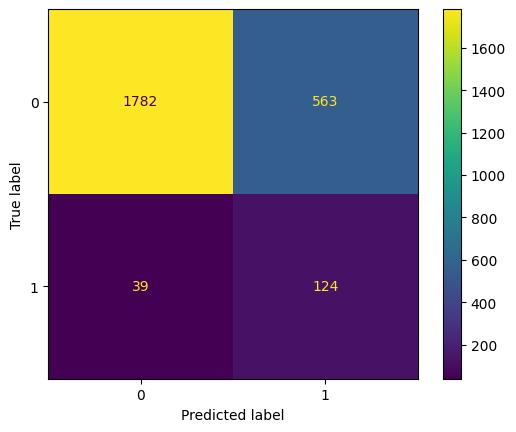

In [35]:
rf_clf.fit(X_train_rus, y_train_rus)
y_pred_test = rf_clf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)

In [38]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced"],
    "bootstrap": [True]
}

gs_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,
    verbose=False
)

gs_rf.fit(X_train_rus, y_train_rus)

print("Mejores params RF:", gs_rf.best_params_)
print("Mejor CV balanced_accuracy RF:", gs_rf.best_score_)

best_rf = gs_rf.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTEST classification_report (RF):")
print(classification_report(y_test, y_pred))

Mejores params RF: {'bootstrap': True, 'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 1000}
Mejor CV balanced_accuracy RF: 0.7874721377912868

TEST classification_report (RF):
              precision    recall  f1-score   support

           0       0.97      0.78      0.86      2345
           1       0.18      0.71      0.29       163

    accuracy                           0.77      2508
   macro avg       0.58      0.74      0.58      2508
weighted avg       0.92      0.77      0.83      2508



#### CatBoost con auto_class_weights="Balanced"

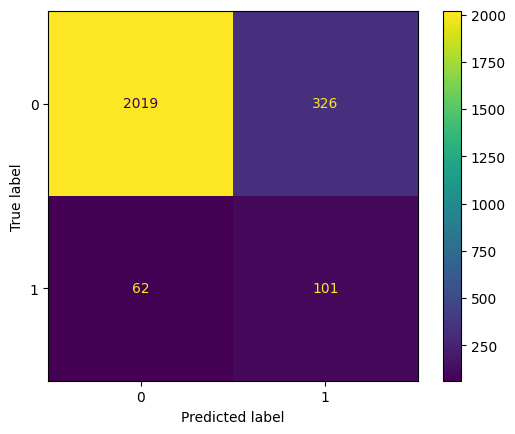

In [39]:
cat_clf_cw.fit(X_train, y_train)
y_pred_test = cat_clf_cw.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores params CatBoost: {'depth': 4, 'iterations': 400, 'l2_leaf_reg': 20, 'learning_rate': 0.03}
Mejor CV balanced_accuracy CatBoost: 0.7794430854472277

TEST classification_report (CatBoost):
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      2345
           1       0.20      0.72      0.32       163

    accuracy                           0.80      2508
   macro avg       0.59      0.76      0.60      2508
weighted avg       0.93      0.80      0.85      2508



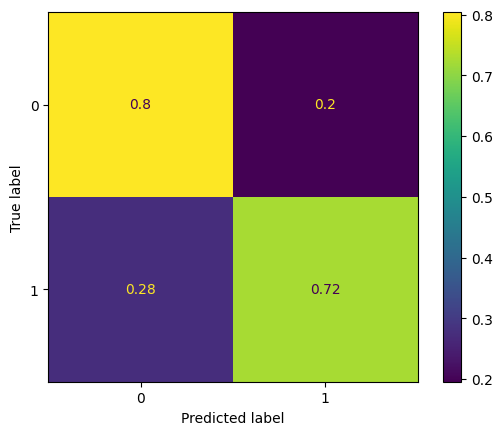

In [42]:
cat = CatBoostClassifier(auto_class_weights="Balanced",loss_function="Logloss",random_seed=42,verbose=False,
    thread_count=1  # importante para que GridSearch paralelice sin explotar CPU
)

param_grid_cat = {
    "depth": [4, 5, 6, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [400, 800, 1200],
    "l2_leaf_reg": [3, 5, 10, 20]
}

gs_cat = GridSearchCV(
    estimator=cat,
    param_grid=param_grid_cat,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1,       # paraleliza la grilla
    verbose=False
)

gs_cat.fit(X_train, y_train)

print("Mejores params CatBoost:", gs_cat.best_params_)
print("Mejor CV balanced_accuracy CatBoost:", gs_cat.best_score_)

best_cat = gs_cat.best_estimator_
y_pred = best_cat.predict(X_test)

print("\nTEST classification_report (CatBoost):")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")